# Analysing Coastal Change with Sentinel

This notebook is a simplified, worked example of analysing multiple years of
Landsat data to locate the coastline, and its change over time.

The original implementation of this algorithm was achieved by Geoscience Australia
and is available at [dea-costlines](https://github.com/geoscienceAustralia/dea-coastlines).
There is a new version, which is more generic available at
[coastlines](https://github.com/auspatious/coastlines).

## Requirements

The algorithm uses two fundameltal datasets, first, optical Earth observation data,
and Landsat is ideal, as it goes back over forty years. And second, is a tidal
model, which is used to annotate scenes with a tide height, and to filter
those scenes to just those in the middle of the tide range, therefore establishing
an 'average' coastline.

## Configuration and setup

First, we import libraries and tools that we need to run the analysis.

In [1]:
import os
import geopandas as gpd

from coastlines.utils import extract_contours, tide_cutoffs
from coastlines.vector import annual_movements, calculate_regressions
from dask.distributed import Client
from datacube import Datacube
from datacube.utils.masking import create_mask_value, valid_data_mask
from dea_tools.spatial import points_on_line
from dea_tools.datahandling import mostcommon_crs
from eo_tides import pixel_tides, tide_stats
from ipyleaflet import basemaps
from odc.geo.geom import point
from odc.stac import configure_s3_access
from odc.geo.geom import Geometry

### Set up our environment

We're going to access Landsat data from USGS using the Element-84 STAC API.

The `configure_s3_access` function will set up the environment for the requester
pays bucket on S3, which USGS shares data from. And we use Dask to lazy-load
data and run the computation in parallel.

In [2]:
# Tide data and config
tide_data_location = "~/jovyan/data/coastlines/tide_models"

# # Configure AWS
# os.environ["AWS_DEFAULT_REGION"] = "us-west-2"

# if "AWS_NO_SIGN_REQUEST" in os.environ:
#     del os.environ["AWS_NO_SIGN_REQUEST"]

# configure_s3_access(requester_pays=True)

# Connect to the Datacube
dc = Datacube(app="coastlines")

# Set up a dask client
dask_client = Client(n_workers=8, threads_per_worker=8)
dask_client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 8
Total threads: 64,Total memory: 32.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:38923,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:44707,Total threads: 8
Dashboard: http://127.0.0.1:44229/status,Memory: 4.00 GiB
Nanny: tcp://127.0.0.1:40589,


### Set up a study location

Configure a spatial location and a time range.

In [14]:
from shapely.geometry import box
import geopandas as gpd
import leafmap.foliumap as leafmap

start_date = "2023"
end_date = "2024"
max_cloud_cover = 25  # Maximum cloud cover percentage

# Find a location you're interested in on Google Maps and copy the coordinates
# by right-clicking on the map and clicking the coordinates

lat_range = (-6.12096, -6.09363)
lon_range = (120.39226, 120.44214) 


# Create a bounding box polygon
area = box(lon_range[0], lat_range[0], lon_range[1], lat_range[1])
gdf = gpd.GeoDataFrame(geometry=[area], crs="EPSG:4326")

# Explore with Esri World Imagery basemap
m = leafmap.Map()
m.add_basemap("HYBRID")
m.add_gdf(gdf, layer_name="Area of Interest")
m

### Find and load data

Search for Landsat scenes and load them into memory using Dask.

In [15]:
categories_to_mask_landsat = {
    "cloud": "high_confidence",
    "cloud_shadow": "high_confidence",
}

# Find and load Landsat datasets
sentinel2_dataset = dc.find_datasets(
    product=["s2_l2a"],
    time=(start_date, end_date),
    longitude=lon_range,
    latitude=lat_range,
    cloud_cover=(0, max_cloud_cover),
)

# Identify the most common projection system in the input query
query = {
    'y': lat_range,
    'x': lon_range,
    'time': (start_date, end_date),
    'resolution': (-20, 20),
}
output_crs = mostcommon_crs(dc=dc, product="s2_l2a", query=query)


print(f"Found {len(sentinel2_dataset)} Sentinel datasets")

data = dc.load(
    datasets=sentinel2_dataset,
    longitude=lon_range,
    latitude=lat_range,
    resolution=20,
    output_crs=output_crs,
    measurements=["red", "green", "blue", "nir08", "swir16", "swir22", "scl"],
    group_by="solar_day",
    dask_chunks={"time": 1, "x": 3200, "y": 3200},
    resampling={
        "*": "cubic",
        "scl": "nearest",
    },
    driver="rio",
)

Found 169 Sentinel datasets


### Preview data

This cell first selects the first four scenes using the `isel` or "index select" function.
And then plots that from an array, so that we get an RGB visualisation.

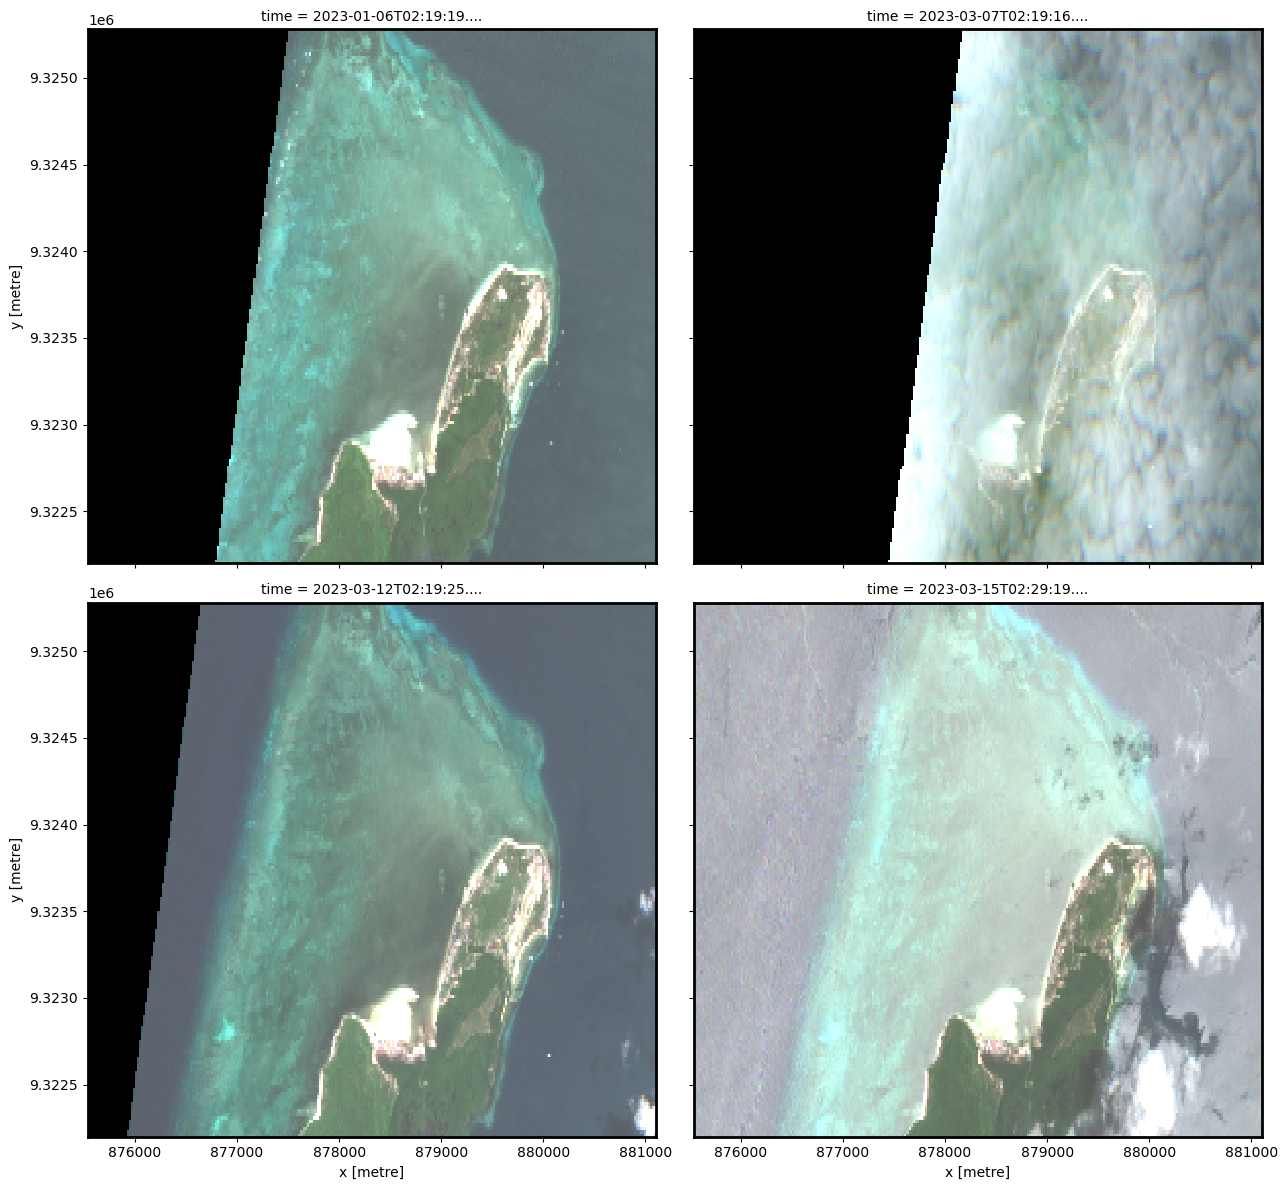

In [16]:
subset = data[["red", "green", "blue"]].isel(time=slice(0, 4))
subset.to_array().plot.imshow(col="time", col_wrap=2, size=6, robust=True)

## Data processing

Now we know we have some good data, we can start processing. First we need to mask
out clouds, so that they don't impact our results.

In [17]:
# Mask Sentinel-2 data
# 3 is cloud shadow, 8 is medium probability cloud, 9 is high probability cloud
cloud_mask = data.scl.isin([3, 8, 9])
valid_data = valid_data_mask(data)
mask = cloud_mask | ~valid_data

s2_ds_masked = data.where(~mask).drop_vars("scl")

# Scale Sentinel-2 data so that values are between 0 and 1
masked = (s2_ds_masked * 0.0001).clip(
    0, 1
)  # Scale Sentinel-2 data to match Landsat scale

masked

<xarray.Dataset> Size: 96MB
Dimensions:      (time: 93, y: 154, x: 278)
Coordinates:
  * y            (y) float64 1kB 9.325e+06 9.325e+06 ... 9.322e+06 9.322e+06
  * x            (x) float64 2kB 8.756e+05 8.756e+05 ... 8.811e+05 8.811e+05
    spatial_ref  int32 4B 32750
  * time         (time) datetime64[ns] 744B 2023-01-06T02:19:19.696000 ... 20...
Data variables:
    red          (time, y, x) float32 16MB dask.array<chunksize=(1, 154, 278), meta=np.ndarray>
    green        (time, y, x) float32 16MB dask.array<chunksize=(1, 154, 278), meta=np.ndarray>
    blue         (time, y, x) float32 16MB dask.array<chunksize=(1, 154, 278), meta=np.ndarray>
    nir08        (time, y, x) float32 16MB dask.array<chunksize=(1, 154, 278), meta=np.ndarray>
    swir16       (time, y, x) float32 16MB dask.array<chunksize=(1, 154, 278), meta=np.ndarray>
    swir22       (time, y, x) float32 16MB dask.array<chunksize=(1, 154, 278), meta=np.ndarray>

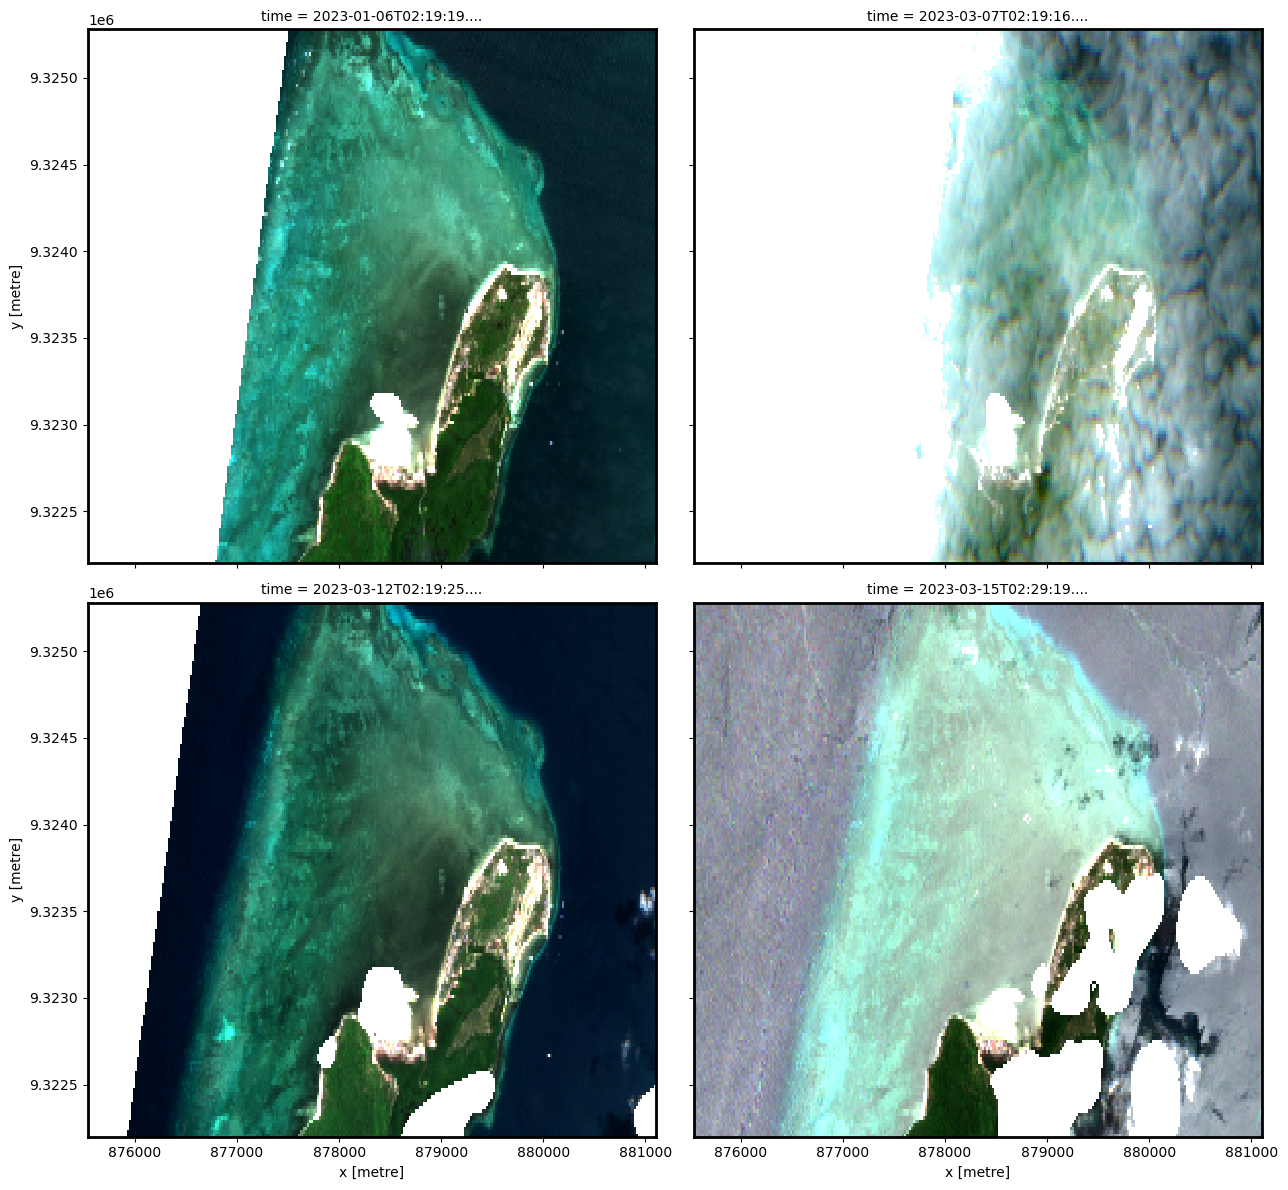

In [18]:
# Preview the masked data
masked_subset = masked[["red", "green", "blue"]].isel(time=range(0, 4))
masked_subset.to_array().plot.imshow(col="time", col_wrap=2, size=6, robust=True)

### Tide masking

This cell filters out scenes that are wholy in the "extreme" tides, or those
outside the middle 50% of observations.

In [19]:
# Add tide height to the data
masked['tide_m'] = pixel_tides(
    masked,
    resample=True,
    directory=tide_data_location,
    model="INATIDES",
    dask_compute=True,
)

# Print modelled tides
masked

Creating reduced resolution 5000 x 5000 metre tide modelling array
Modelling tides with INATIDES
Reprojecting tides into original resolution


/opt/conda/lib/python3.12/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(
/opt/conda/lib/python3.12/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(
/opt/conda/lib/python3.12/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(
/opt/conda/lib/python3.12/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


<xarray.Dataset> Size: 111MB
Dimensions:      (time: 93, y: 154, x: 278)
Coordinates:
  * y            (y) float64 1kB 9.325e+06 9.325e+06 ... 9.322e+06 9.322e+06
  * x            (x) float64 2kB 8.756e+05 8.756e+05 ... 8.811e+05 8.811e+05
    spatial_ref  int32 4B 32750
  * time         (time) datetime64[ns] 744B 2023-01-06T02:19:19.696000 ... 20...
    tide_model   <U8 32B 'INATIDES'
Data variables:
    red          (time, y, x) float32 16MB dask.array<chunksize=(1, 154, 278), meta=np.ndarray>
    green        (time, y, x) float32 16MB dask.array<chunksize=(1, 154, 278), meta=np.ndarray>
    blue         (time, y, x) float32 16MB dask.array<chunksize=(1, 154, 278), meta=np.ndarray>
    nir08        (time, y, x) float32 16MB dask.array<chunksize=(1, 154, 278), meta=np.ndarray>
    swir16       (time, y, x) float32 16MB dask.array<chunksize=(1, 154, 278), meta=np.ndarray>
    swir22       (time, y, x) float32 16MB dask.array<chunksize=(1, 154, 278), meta=np.ndarray>
    tide_m       (time, y, x) float32 16MB -0.1154 -0.1152 ... 0.0423 0.04267

Using tide modelling location: 120.42, -6.11
Modelling tides with INATIDES
Using tide modelling location: 120.42, -6.11
Modelling tides with INATIDES


🌊 Modelled astronomical tide range: 2.38 m (-1.36 to 1.03 m).
🛰️ Observed tide range: 1.65 m (-0.94 to 0.71 m).

🔴 69% of the modelled astronomical tide range was observed at this location.
🟡 The highest 13% (0.32 m) of the tide range was never observed.
🟡 The lowest 17% (0.42 m) of the tide range was never observed.

🌊 Mean modelled astronomical tide height: -0.00 m.
🛰️ Mean observed tide height: 0.00 m.
⬆️ The mean observed tide height was 0.01 m higher than the mean modelled astronomical tide height.


mot              0.005
mat             -0.001
hot              0.710
hat              1.027
lot             -0.940
lat             -1.356
otr              1.649
tr               2.384
spread           0.692
offset_low       0.175
offset_high      0.133
x              120.417
y               -6.107
dtype: float32

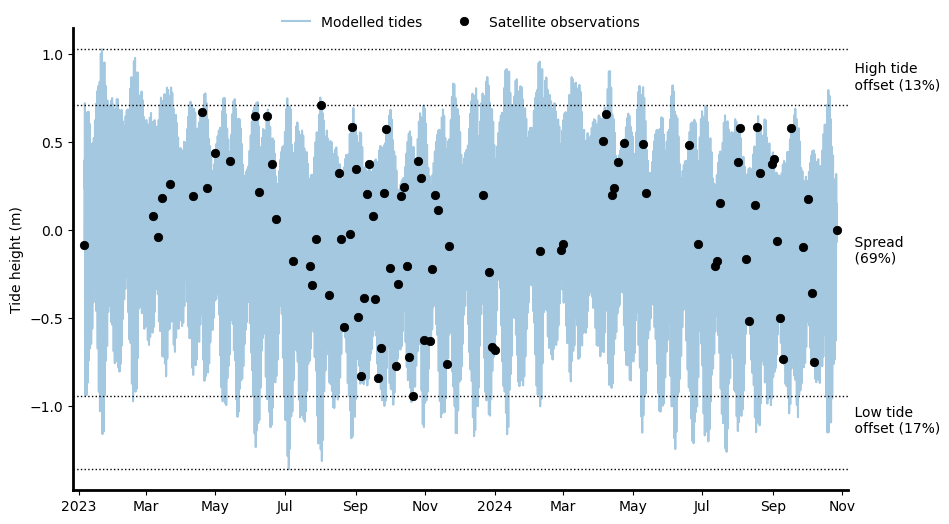

In [20]:
# Display tides statistic
stats = tide_stats(
    data=masked,
    model="INATIDES",
    directory=tide_data_location,
)
stats

In [21]:
# Calculate low and high tide height thresholds
# lowtide_cutoff = float(stats['mot'])
# hightide_cutoff = float(stats['hot'])
lowtide_cutoff = 0.005
hightide_cutoff = 0.710
lowtide_thresh, hightide_thresh = masked.tide_m.quantile([lowtide_cutoff, hightide_cutoff])
print(f"Low tide threshold: {lowtide_thresh:.2f} metres AMSL")
print(f"High tide threshold: {hightide_thresh:.2f} metres AMSL")

Low tide threshold: -0.96 metres AMSL
High tide threshold: 0.27 metres AMSL


In [36]:
# Get high tide images (above the high tide threshold)
data_tide_masked = masked.where(
    (masked.tide_m >= -0.3) & (masked.tide_m <= 0.3), 
    drop=True
)
data_tide_masked

<xarray.Dataset> Size: 60MB
Dimensions:      (time: 50, y: 154, x: 278)
Coordinates:
  * y            (y) float64 1kB 9.325e+06 9.325e+06 ... 9.322e+06 9.322e+06
  * x            (x) float64 2kB 8.756e+05 8.756e+05 ... 8.811e+05 8.811e+05
    spatial_ref  int32 4B 32750
  * time         (time) datetime64[ns] 400B 2023-01-06T02:19:19.696000 ... 20...
    tide_model   <U8 32B 'INATIDES'
Data variables:
    red          (time, y, x) float32 9MB dask.array<chunksize=(1, 154, 278), meta=np.ndarray>
    green        (time, y, x) float32 9MB dask.array<chunksize=(1, 154, 278), meta=np.ndarray>
    blue         (time, y, x) float32 9MB dask.array<chunksize=(1, 154, 278), meta=np.ndarray>
    nir08        (time, y, x) float32 9MB dask.array<chunksize=(1, 154, 278), meta=np.ndarray>
    swir16       (time, y, x) float32 9MB dask.array<chunksize=(1, 154, 278), meta=np.ndarray>
    swir22       (time, y, x) float32 9MB dask.array<chunksize=(1, 154, 278), meta=np.ndarray>
    tide_m       (time, y, x) float32 9MB -0.1154 -0.1152 ... 0.0423 0.04267

### Identify land and water

We use a water index, here it's a combination of the normalised difference wetness index, NDWI,
and the modified version of that, MNDWI. We find the average of the two indices, which has been
found to be more robust to issues of noisy data over ocean in Landsat.

In [37]:
# # # Create Combined index (the mean of MNDWI and NDWI)
index_name = "combined"
data_tide_masked["mndwi"] = (data_tide_masked.green - data_tide_masked.swir16) / (data_tide_masked.green + data_tide_masked.swir16)
data_tide_masked["ndwi"] = (data_tide_masked.green - data_tide_masked.nir08) / (data_tide_masked.green + data_tide_masked.nir08)
data_tide_masked["combined"] = (data_tide_masked.mndwi + data_tide_masked.ndwi) / 2

# # Create SCOWI index, which is an alternative to the above combined index
# index_name = "scowi"
# d = data_tide_masked
# data_tide_masked["scowi"] = d.blue + 2 * (d.green - d.nir08) - 0.75 * (d.swir16) - 0.5 * (d.swir16)

# # Create MNDWI_NIR index
# index_name = "mndwi_nir"
# scaled_green = (
#     data_tide_masked.green
#     + (data_tide_masked.nir08.max(dim="time") - data_tide_masked.nir08)
# ) / 2
# scaled_swir1 = (data_tide_masked.swir16 + data_tide_masked.nir08) / 2
# data_tide_masked["mndwi_nir"] = (scaled_green - scaled_swir1) / (
#     scaled_green + scaled_swir1
# )

grouped_by_year = (
    data_tide_masked[index_name]
    .groupby("time.year")
    .median()
    .to_dataset(name=index_name)
)
grouped_by_year = grouped_by_year.compute()

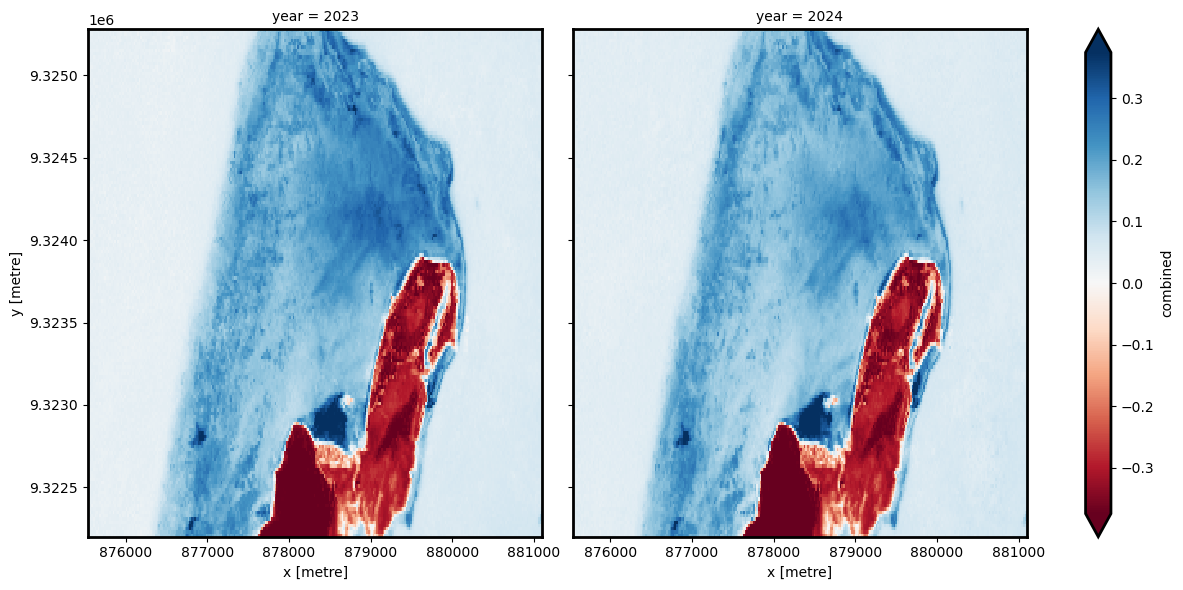

In [38]:
grouped_by_year[index_name].plot.imshow(
    col="year", col_wrap=2, size=6, cmap="RdBu", robust=True
)

### Extract contours

Next we extract contour lines from the underlying land/water raster data.

In [39]:
# You can also try using the other index above
# use z_value of 0.0 for 'mndwi'
# use z_value of 0.65 for `mndwi_nir`
z_values = 0

contour_gdf = extract_contours(
    grouped_by_year, z_values=z_values, index_name=index_name
)

contour_gdf.reset_index().explore(
    column="year",
    cmap="magma",
    style_kwds={"weight": 3},
    tiles=basemaps.Esri.WorldImagery,
)


### Extract points

And from the contours, we extract points, and annotate them with change over time, so that
we can document how much the coastline has eroded or accreted.

In [40]:
# Export results to GeoPackage
location = "MSL_COASTLINE"
# points_gdf.to_file(f"{location}_rate_of_change.gpkg", layer="rate_of_change", driver="GPKG")
contour_gdf.to_file(f"{location}_shorlines.gpkg", layer="shorelines", driver="GPKG")

## Explore a full timeseries

Have a look at the [full map of results here](https://map.asia.easi-eo.solutions).

Click "explore map data" and then add "Indonesian Coastlines", which contains five sites across Indonesia.